# Clustering Stratifié pour le Split Train / Test

**Objectif** : garantir un split train/test **représentatif** du stock résidentiel en effectuant un clustering
indépendant sur chaque groupe métier, puis en agrégeant les labels pour construire un stratum composite.

**Pipeline** :
1. Clustering KMeans par groupe de features (7 groupes)
2. Analyse de chaque clustering (elbow, silhouette, centroïdes)
3. Agrégation → stratum composite
4. `train_test_split(stratify=stratum)` équilibré
5. Sauvegarde des indices

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

ROOT           = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / 'data' / 'processed'

RANDOM_STATE = 42
TEST_SIZE    = 0.20

print('Libs OK')

Libs OK


## 1. Chargement des données

In [2]:
X = pd.read_parquet(DATA_PROCESSED / 'X.parquet')
Y = pd.read_parquet(DATA_PROCESSED / 'Y.parquet')

print(f'X : {X.shape}  |  Y : {Y.shape}')
print(f'NaN dans X : {X.isna().sum().sum()}')
X.dtypes.value_counts()

X : (549971, 108)  |  Y : (549971, 5)
NaN dans X : 0


int64      34
float32    26
float64    23
Int8       16
int8        9
Name: count, dtype: int64

## 2. Définition des groupes de features

In [ ]:

GROUPES = {

    # ── G1 : Socio-Économiques ────────────────────────────────────────────────
    'G1_SocioEco': [
        'in.income',
        'in.tenure',
    ],

    # ── G2 : Occupants ────────────────────────────────────────────────────────
    'G2_Occupants': [
        'in.occupants',
        'in.vacancy_status',
        'in.usage_level',
    ],

    # ── G3 : Météo → zone ASHRAE directement (pas KMeans) ────────────────────
    # Chargé depuis metadata_clean.parquet : in.ashrae_iecc_climate_zone_2004

    # ── G4a : Isolation & Étanchéité ─────────────────────────────────────────
    'G4a_Isolation': [
        'in.insulation_ceiling',
        'in.insulation_wall',
        'in.insulation_roof',
        'in.insulation_floor',
        'in.insulation_foundation_wall',
        'in.air_leakage_to_outside_ach50',
        'in.window_ufactor',
        'in.window_shgc',
        'in.window_front',
        'in.roof_material',
    ],

    # ── G4b : Géométrie & Voisinage ───────────────────────────────────────────
    'G4b_Geometrie': [
        'in.geometry_floor_area',
        'in.vintage',
        'in.geometry_stories',
        'in.geometry_attic_type',
        'in.geometry_foundation_type',
        'in.geometry_garage',
        'in.bedrooms',
        'in.corridor',
        'in.orientation_sin',
        'in.orientation_cos',
        'in.horiz_loc_Middle',
        'in.horiz_loc_Right',
        'in.neighbor_distance_ft',
        'in.neighbor_both_sides',
    ],

    # ── G5a : HVAC ────────────────────────────────────────────────────────────
    'G5a_HVAC': [
        'in.hvac_has_ducts',
        'in.heating_setpoint',
        'in.cooling_setpoint',
        'in.hvac_cooling_efficiency',
        'in.hvac_has_zonal_electric_heating',
        'in.cooling_setpoint_has_offset',
        'in.heating_setpoint_has_offset',
        'in.cooling_setpoint_offset_magnitude',
        'in.heating_setpoint_offset_magnitude',
        'in.hvac_cooling_partial_space_conditioning',
        'in.duct_location_int',
        'in.duct_leakage',
        'in.duct_insulation',
    ],

    # ── G5b : ECS / Chauffe-eau ───────────────────────────────────────────────
    'G5b_ECS': [
        'in.water_heater_efficiency',
        'in.water_heater_fuel_natural_gas',
        'in.water_heater_technology_storage',
        'in.water_heater_technology_tankless',
        'in.water_heater_location_unconditioned',
        'in.water_heater_location_semi_conditioned',
        'in.water_heater_technology_indirect',
        'in.water_heater_fuel_propane',
        'in.water_heater_in_unit',
        'in.hot_water_fixtures',
    ],

    # ── G6 : Usages Blancs (électroménager) ──────────────────────────────────
    'G6_UsagesBlancs': [
        'in.clothes_dryer_efficiency', 'in.clothes_dryer_has',
        'in.clothes_dryer_electric',   'in.clothes_dryer_gas',
        'in.clothes_dryer_usage_level',
        'in.clothes_washer_efficiency', 'in.clothes_washer_has',
        'in.refrigerator_ef', 'in.refrigerator_has',
        'in.refrigerator_usage_level',
        'in.misc_extra_refrigerator_ef', 'in.misc_extra_refrigerator_has',
        'in.misc_freezer_ef',
        'in.lighting_efficiency',
        'in.has_well_pump',
        'in.has_ceiling_fan', 'in.ceiling_fan_used',
        'in.dishwasher_kwh',  'in.has_dishwasher',
    ],

    # ── G7 : Usages Bruns (TV, PC, chargeurs) ────────────────────────────────
    'G7_UsagesBruns': [
        'in.plug_loads',
        'in.plug_load_diversity',
    ],
}

# Verification
all_cols = [c for cols in GROUPES.values() for c in cols]
manquantes = [c for c in all_cols if c not in X.columns]
print(f'Colonnes definies : {len(all_cols)}  |  Manquantes : {manquantes}')
print()
for g, cols in GROUPES.items():
    cols_ok = [c for c in cols if c in X.columns]
    print(f'{g:22s} : {len(cols_ok):3d} features')
print(f'\nTotal features pour le clustering : {len(all_cols)} / {len(X.columns)}')


In [4]:
# Verification : couverture des attributs de X.parquet
x_cols       = set(X.columns)
grouped_cols = set(c for cols in GROUPES.values() for c in cols)

non_assigned   = sorted(x_cols - grouped_cols)
missing_from_x = sorted(grouped_cols - x_cols)

print(f"X.parquet             : {len(x_cols)} colonnes")
print(f"Colonnes dans GROUPES : {len(grouped_cols)}")
print()

if non_assigned:
    print(f"[WARN] Dans X mais NON assignees a un groupe ({len(non_assigned)}) :")
    for c in non_assigned:
        print(f"   - {c}")
else:
    print("[OK] Toutes les colonnes de X sont assignees a un groupe.")

print()

if missing_from_x:
    print(f"[WARN] Dans GROUPES mais ABSENTES de X ({len(missing_from_x)}) :")
    for c in missing_from_x:
        print(f"   - {c}")
else:
    print("[OK] Toutes les colonnes des groupes existent dans X.")

print()
print("-- Detail par groupe ------------------------------------------")
total = 0
for g, cols in GROUPES.items():
    ok     = [c for c in cols if c in x_cols]
    ko     = [c for c in cols if c not in x_cols]
    status = "OK" if not ko else "MANQUE"
    manque = f"  | MANQUE : {ko}" if ko else ""
    print(f"  [{status:6s}]  {g:22s} : {len(ok):3d}/{len(cols)} features{manque}")
    total += len(ok)
print(f"\n  Total features pour le clustering : {total} / {len(x_cols)}")


X.parquet             : 108 colonnes
Colonnes dans GROUPES : 63

[WARN] Dans X mais NON assignees a un groupe (45) :
   - in.aiannh_area
   - in.area_median_income
   - in.clothes_dryer_usage_level
   - in.duct_insulation
   - in.electric_panel_breaker_space_total_count
   - in.electric_panel_service_rating..a
   - in.electric_vehicle_charge_at_home
   - in.electric_vehicle_charger
   - in.electric_vehicle_miles_traveled
   - in.federal_poverty_level
   - in.has_hot_tub
   - in.has_pool
   - in.has_pv
   - in.horiz_loc_Middle
   - in.horiz_loc_Right
   - in.hot_tub_electric
   - in.hot_water_fixtures
   - in.household_has_tribal_persons
   - in.misc_gas_fireplace_present
   - in.misc_gas_grill_present
   - in.misc_gas_lighting_present
   - in.misc_hot_tub_gas
   - in.neighbor_both_sides
   - in.neighbor_distance_ft
   - in.pool_heater_electric
   - in.pool_heater_gas
   - in.pool_heater_present
   - in.pv_system_size
   - in.refrigerator_usage_level
   - in.slab_perimeter_r
   - in.sla

## 3. Fonctions utilitaires

In [5]:
def elbow_silhouette(X_scaled, k_range=range(2, 9), name='', sample_sil=20_000):
    """Calcule inertie et silhouette pour chaque k. Retourne (inertias, silhouettes)."""
    inertias, silhouettes = [], []
    idx_sample = np.random.choice(len(X_scaled), min(sample_sil, len(X_scaled)), replace=False)
    X_sil = X_scaled[idx_sample]

    for k in k_range:
        km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                             batch_size=10_000, n_init=3)
        labels_all  = km.fit_predict(X_scaled)
        labels_sil  = labels_all[idx_sample]
        inertias.append(km.inertia_)
        sil = silhouette_score(X_sil, labels_sil, sample_size=min(5000, len(X_sil)))
        silhouettes.append(sil)
        print(f'  k={k}  inertie={km.inertia_:,.0f}  silhouette={sil:.3f}')

    return list(k_range), inertias, silhouettes


def plot_elbow(k_range, inertias, silhouettes, name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax1.plot(k_range, inertias, 'o-', color='steelblue')
    ax1.set(title=f'{name} — Elbow (inertie)', xlabel='k', ylabel='Inertie')
    ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax2.plot(k_range, silhouettes, 's-', color='coral')
    ax2.set(title=f'{name} — Silhouette', xlabel='k', ylabel='Score silhouette')
    ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()


def cluster_group(X_df, cols, k, name):
    """Scale + KMeans sur un groupe. Retourne (labels, scaler, model, X_scaled)."""
    cols = [c for c in cols if c in X_df.columns]
    X_g  = X_df[cols].astype(float).values
    sc   = StandardScaler()
    Xs   = sc.fit_transform(X_g)
    km   = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                           batch_size=10_000, n_init=5, max_iter=300)
    labels = km.fit_predict(Xs)
    print(f'{name} | k={k} | inertie={km.inertia_:,.0f}')
    print(pd.Series(labels).value_counts().sort_index().to_string())
    return labels, sc, km, Xs


def analyse_cluster(X_df, cols, labels, km, sc, name, n_top=8):
    """Heatmap des centroïdes (features les plus discriminantes)."""
    cols   = [c for c in cols if c in X_df.columns]
    k      = km.n_clusters
    # Centroïdes en espace original
    cents  = sc.inverse_transform(km.cluster_centers_)
    df_c   = pd.DataFrame(cents, columns=cols)

    # Variance entre clusters (pour trier les features les plus discriminantes)
    var    = df_c.var(axis=0).sort_values(ascending=False)
    top_f  = var.index[:n_top].tolist()

    # Normaliser chaque feature entre 0 et 1 pour la heatmap
    df_plot = df_c[top_f].copy()
    df_plot = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min() + 1e-9)

    sizes = pd.Series(labels).value_counts().sort_index()
    row_labels = [f'Cluster {i} (n={sizes[i]:,})' for i in range(k)]

    fig, ax = plt.subplots(figsize=(max(10, len(top_f)*1.1), 3 + k*0.5))
    sns.heatmap(df_plot.values, xticklabels=[c.replace('in.','') for c in top_f],
                yticklabels=row_labels, annot=df_c[top_f].values.round(2),
                fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.4)
    ax.set_title(f'{name} — Centroïdes (top {len(top_f)} features discriminantes)', pad=10)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

print('Fonctions chargées.')

Fonctions chargées.


---
## 4. Clustering par groupe

| Groupe | Features | Méthode |
|---|---|---|
| G1 Socio-Éco | 2 | KMeans |
| G2 Occupants | 2 | KMeans |
| G3 Météo | 13 zones | **ASHRAE direct** |
| G4a Isolation & Étanchéité | 9 | KMeans |
| G4b Géométrie | 6 | KMeans |
| G5a HVAC | 12 | KMeans |
| G5b ECS | 8 | KMeans |
| G6 Usages Blancs | 17 | KMeans |
| G7 Usages Bruns | 2 | KMeans |

### G1 — Variables Socio-Économiques

Elbow / silhouette pour G1_SocioEco (2 features) :


  k=2  inertie=495,141  silhouette=0.604


  k=3  inertie=201,023  silhouette=0.655


  k=4  inertie=137,990  silhouette=0.657


  k=5  inertie=99,753  silhouette=0.606


  k=6  inertie=62,973  silhouette=0.632


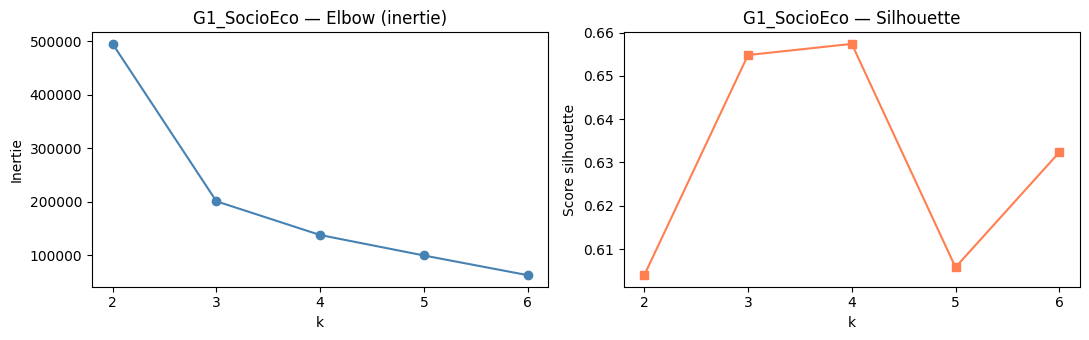

In [6]:
g = 'G1_SocioEco'
cols_g1 = [c for c in GROUPES[g] if c in X.columns]

Xs_g1_tmp = StandardScaler().fit_transform(X[cols_g1].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g1)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g1_tmp, range(2, 7), name=g)
plot_elbow(k_range, inertias, sils, g)

G1_SocioEco | k=3 | inertie=201,028
0    169701
1    254950
2    125320


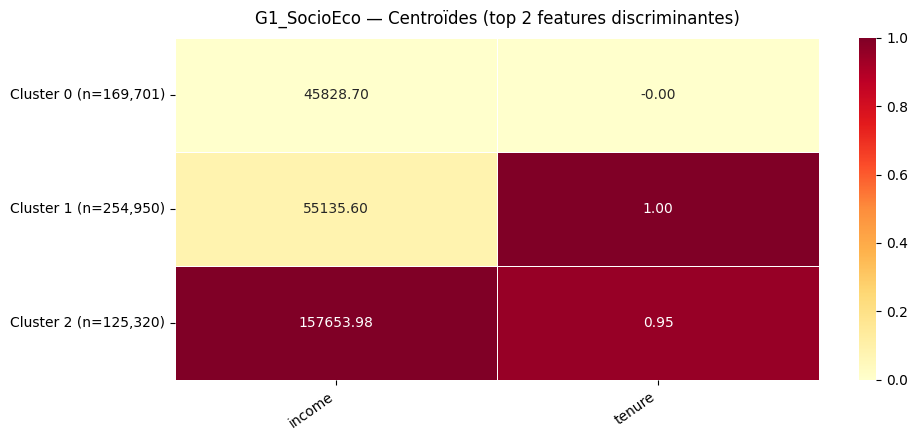

In [7]:
K_G1 = 3   # ← ajuster selon elbow

labels_g1, sc_g1, km_g1, Xs_g1 = cluster_group(X, cols_g1, K_G1, g)
analyse_cluster(X, cols_g1, labels_g1, km_g1, sc_g1, g)

### G2 — Variables Occupants

Elbow / silhouette pour G2_Occupants (3 features) :


  k=2  inertie=950,458  silhouette=0.587


  k=3  inertie=628,247  silhouette=0.474


  k=4  inertie=415,739  silhouette=0.497


  k=5  inertie=294,891  silhouette=0.575


  k=6  inertie=252,293  silhouette=0.582


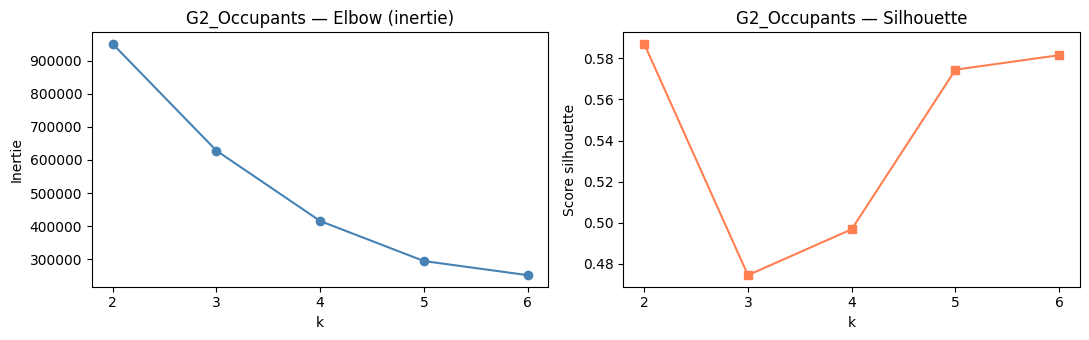

In [8]:
g = 'G2_Occupants'
cols_g2 = [c for c in GROUPES[g] if c in X.columns]

Xs_g2_tmp = StandardScaler().fit_transform(X[cols_g2].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g2)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g2_tmp, range(2, 7), name=g)
plot_elbow(k_range, inertias, sils, g)

G2_Occupants | k=3 | inertie=628,260
0    120757
1    362577
2     66637


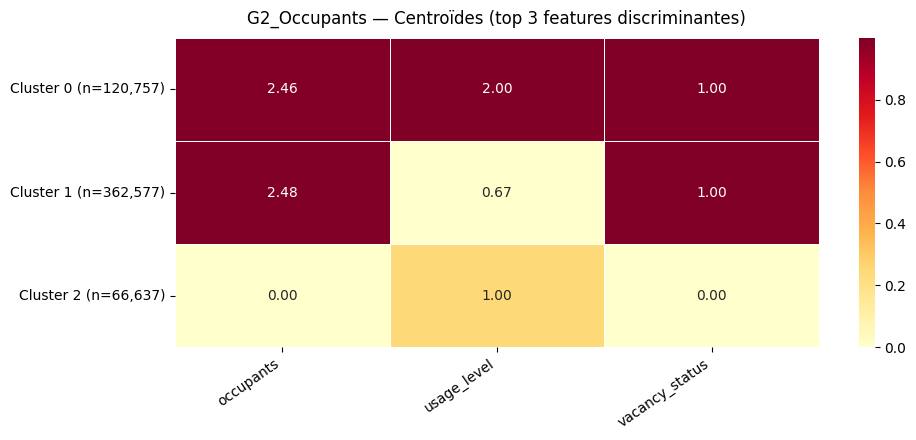

In [9]:
K_G2 = 3   # ← ajuster

labels_g2, sc_g2, km_g2, Xs_g2 = cluster_group(X, cols_g2, K_G2, g)
analyse_cluster(X, cols_g2, labels_g2, km_g2, sc_g2, g)

### G3 — Météo (Zone ASHRAE — stratum direct, pas KMeans)

In [10]:
# G3 : on charge la zone ASHRAE depuis metadata_clean (pas de KMeans)
meta = pd.read_parquet(DATA_PROCESSED / 'metadata_clean.parquet')
labels_g3 = meta['in.ashrae_iecc_climate_zone_2004'].values

print('G3 Météo — Distribution des zones ASHRAE :')
print(pd.Series(labels_g3).value_counts().sort_index().to_string())
print(f'\n{pd.Series(labels_g3).nunique()} zones climatiques distinctes')

G3 Météo — Distribution des zones ASHRAE :
1A       9855
2A      63763
2B      10859
3A      73177
3B      51101
3C      12894
4A     118416
4B       4252
4C      15840
5A     123952
5B      20841
6A      33724
6B       5077
7A       4343
7AK       969
7B        622
8AK       286

17 zones climatiques distinctes


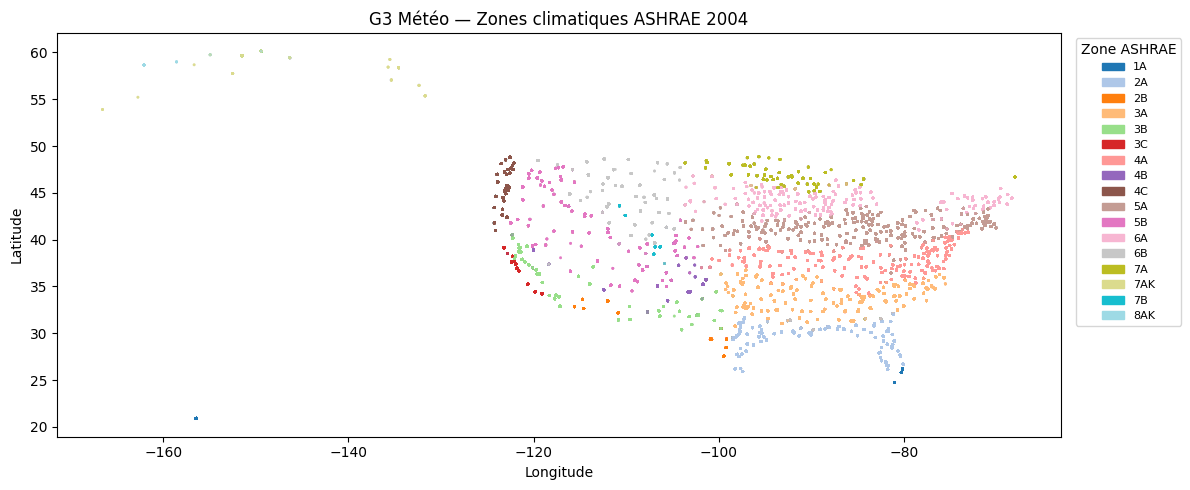

In [11]:
# Visualisation géographique des zones ASHRAE
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

zones   = pd.Series(labels_g3)
uniq    = sorted(zones.unique())
cmap    = plt.cm.get_cmap('tab20', len(uniq))
z2int   = {z: i for i, z in enumerate(uniq)}
colors  = zones.map(z2int)

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(
    meta['in.weather_file_longitude'], meta['in.weather_file_latitude'],
    c=colors, cmap=cmap, s=1, alpha=0.4, vmin=0, vmax=len(uniq)-1
)
patches = [mpatches.Patch(color=cmap(z2int[z]), label=z) for z in uniq]
ax.legend(handles=patches, title='Zone ASHRAE', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=8)
ax.set(xlabel='Longitude', ylabel='Latitude',
       title='G3 Météo — Zones climatiques ASHRAE 2004')
plt.tight_layout()
plt.show()

### G4a — Isolation & Étanchéité

Elbow / silhouette pour G4a_Isolation (9 features) :


  k=2  inertie=4,115,845  silhouette=0.180


  k=3  inertie=3,718,353  silhouette=0.150


  k=4  inertie=3,486,067  silhouette=0.170


  k=5  inertie=2,990,781  silhouette=0.163


  k=6  inertie=2,610,726  silhouette=0.183


  k=7  inertie=2,495,880  silhouette=0.192


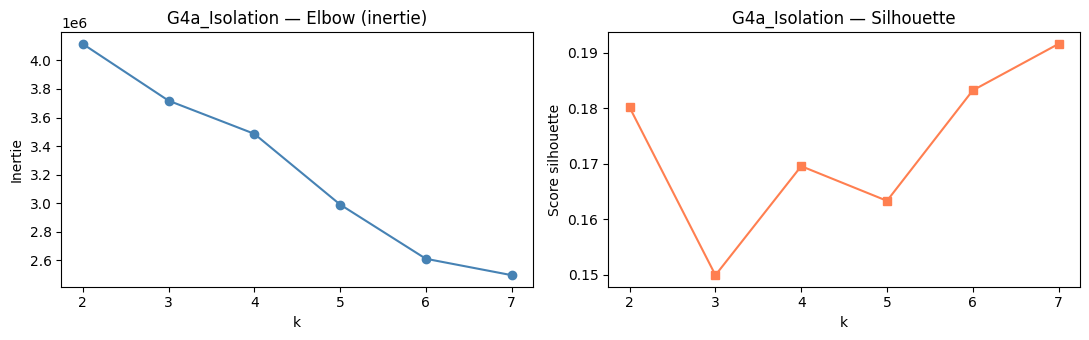

In [12]:
g = 'G4a_Isolation'
cols_g4a = [c for c in GROUPES[g] if c in X.columns]

Xs_g4a_tmp = StandardScaler().fit_transform(X[cols_g4a].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g4a)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g4a_tmp, range(2, 8), name=g)
plot_elbow(k_range, inertias, sils, g)

G4a_Isolation | k=4 | inertie=3,277,228
0    224376
1    106329
2    149781
3     69485


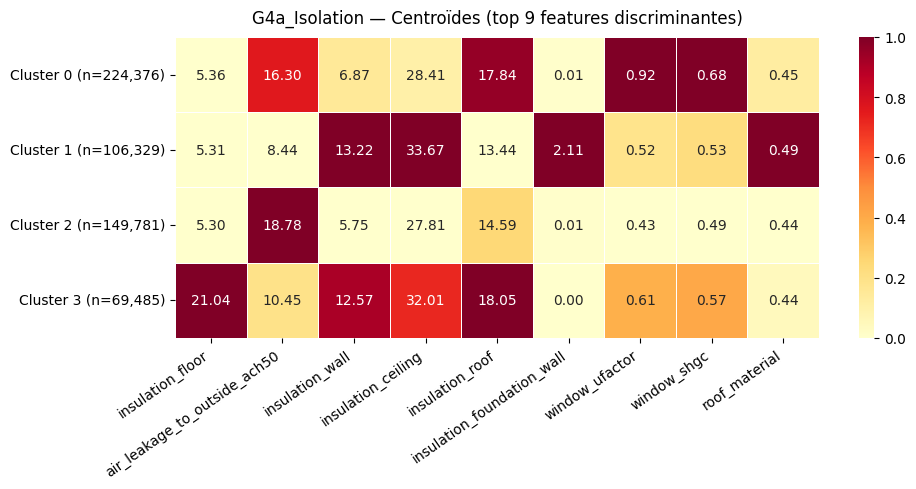


Elbow / silhouette pour G4b_Geometrie (10 features) :


  k=2  inertie=4,345,048  silhouette=0.230


  k=3  inertie=3,848,238  silhouette=0.167


  k=4  inertie=3,500,175  silhouette=0.182


  k=5  inertie=3,280,664  silhouette=0.146


  k=6  inertie=2,913,901  silhouette=0.172


  k=7  inertie=2,813,663  silhouette=0.167


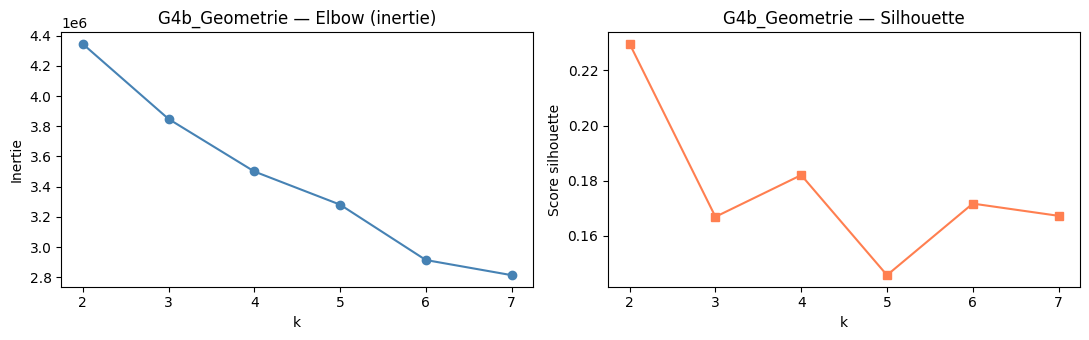

G4b_Geometrie | k=4 | inertie=3,422,693
0    144201
1    131146
2    110763
3    163861


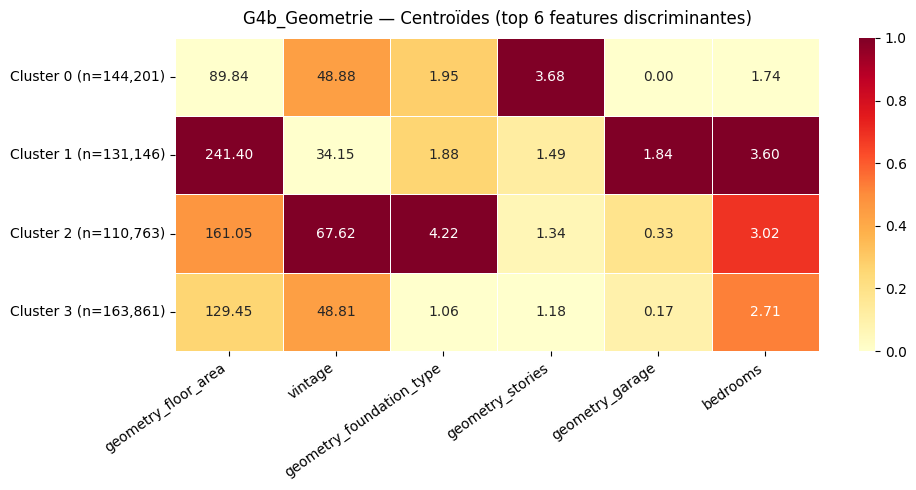

In [13]:
K_G4a = 4   # ← ajuster (ex: très mal isolé / mal isolé / standard / performant)

labels_g4a, sc_g4a, km_g4a, Xs_g4a = cluster_group(X, cols_g4a, K_G4a, g)
analyse_cluster(X, cols_g4a, labels_g4a, km_g4a, sc_g4a, g, n_top=9)

# ── G4b : Géométrie ───────────────────────────────────────────────────────────
g = 'G4b_Geometrie'
cols_g4b = [c for c in GROUPES[g] if c in X.columns]

Xs_g4b_tmp = StandardScaler().fit_transform(X[cols_g4b].astype(float).values)
print(f'\nElbow / silhouette pour {g} ({len(cols_g4b)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g4b_tmp, range(2, 8), name=g)
plot_elbow(k_range, inertias, sils, g)

K_G4b = 4   # ← ajuster (ex: studio/petit / moyen / grand / très grand)

labels_g4b, sc_g4b, km_g4b, Xs_g4b = cluster_group(X, cols_g4b, K_G4b, g)
analyse_cluster(X, cols_g4b, labels_g4b, km_g4b, sc_g4b, g, n_top=6)

### G5a — HVAC

Elbow / silhouette pour G5a_HVAC (12 features) :


  k=2  inertie=5,715,489  silhouette=0.156


  k=3  inertie=5,134,080  silhouette=0.166


  k=4  inertie=4,538,917  silhouette=0.147


  k=5  inertie=4,227,544  silhouette=0.150


  k=6  inertie=4,010,667  silhouette=0.176


  k=7  inertie=3,807,492  silhouette=0.166


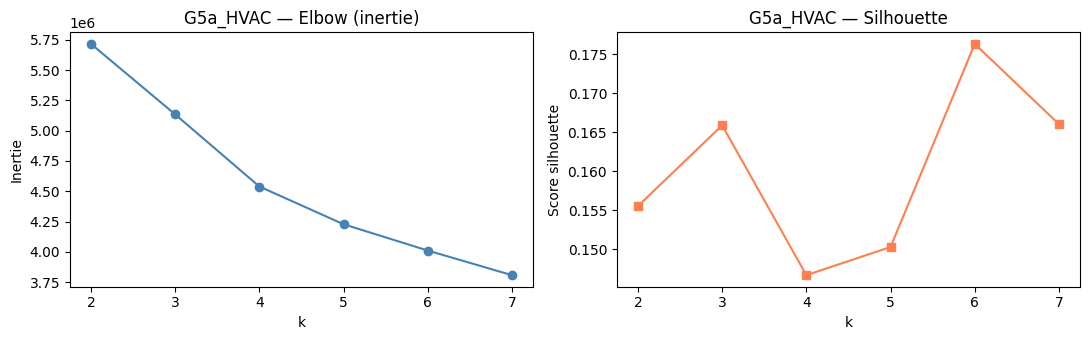

In [14]:
g = 'G5a_HVAC'
cols_g5a = [c for c in GROUPES[g] if c in X.columns]

Xs_g5a_tmp = StandardScaler().fit_transform(X[cols_g5a].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g5a)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g5a_tmp, range(2, 8), name=g)
plot_elbow(k_range, inertias, sils, g)

G5a_HVAC | k=4 | inertie=4,539,783
0    156488
1    137396
2    130469
3    125618


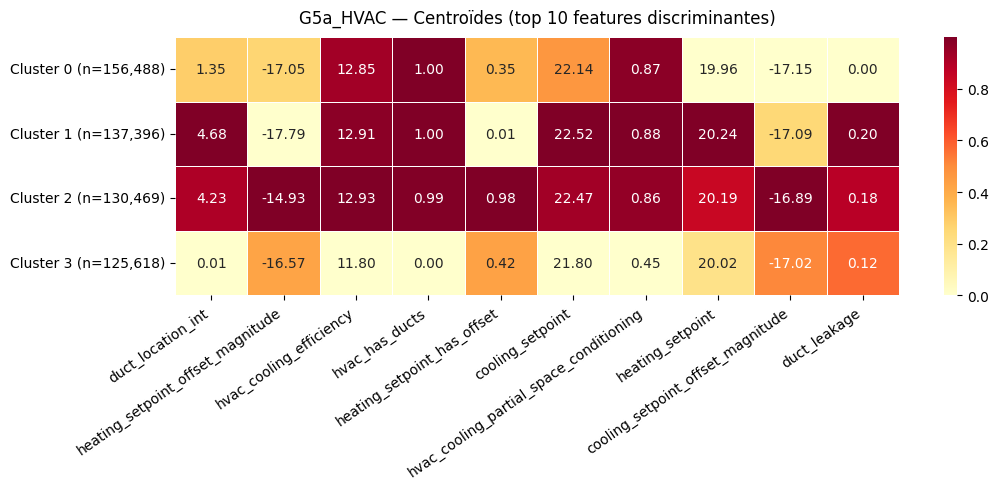


Elbow / silhouette pour G5b_ECS (8 features) :


  k=2  inertie=3,340,500  silhouette=0.631


  k=3  inertie=2,644,392  silhouette=0.479


  k=4  inertie=2,210,528  silhouette=0.516


  k=5  inertie=1,599,352  silhouette=0.548


  k=6  inertie=1,197,077  silhouette=0.657


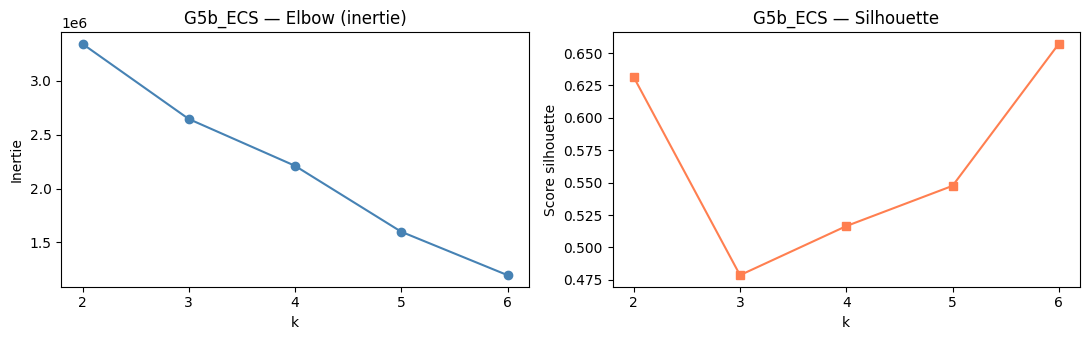

G5b_ECS | k=3 | inertie=2,644,352
0    282453
1     34553
2    232965


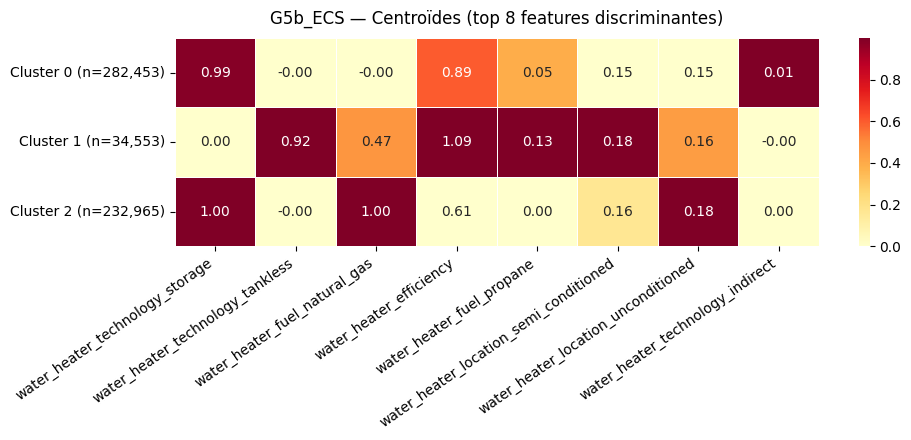

In [15]:
K_G5a = 4   # ← ajuster (ex: gaz/élec + thermostat programmable ou non)

labels_g5a, sc_g5a, km_g5a, Xs_g5a = cluster_group(X, cols_g5a, K_G5a, g)
analyse_cluster(X, cols_g5a, labels_g5a, km_g5a, sc_g5a, g, n_top=10)

# ── G5b : ECS ─────────────────────────────────────────────────────────────────
g = 'G5b_ECS'
cols_g5b = [c for c in GROUPES[g] if c in X.columns]

Xs_g5b_tmp = StandardScaler().fit_transform(X[cols_g5b].astype(float).values)
print(f'\nElbow / silhouette pour {g} ({len(cols_g5b)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g5b_tmp, range(2, 7), name=g)
plot_elbow(k_range, inertias, sils, g)

K_G5b = 3   # ← ajuster (ex: élec standard / gaz standard / élec haute perf)

labels_g5b, sc_g5b, km_g5b, Xs_g5b = cluster_group(X, cols_g5b, K_G5b, g)
analyse_cluster(X, cols_g5b, labels_g5b, km_g5b, sc_g5b, g, n_top=8)

### G6 — Usages Blancs (électroménager)

Elbow / silhouette pour G6_UsagesBlancs (17 features) :


  k=2  inertie=7,123,268  silhouette=0.332


  k=3  inertie=6,147,741  silhouette=0.239


  k=4  inertie=5,502,761  silhouette=0.251


  k=5  inertie=5,234,191  silhouette=0.200


  k=6  inertie=4,981,363  silhouette=0.235


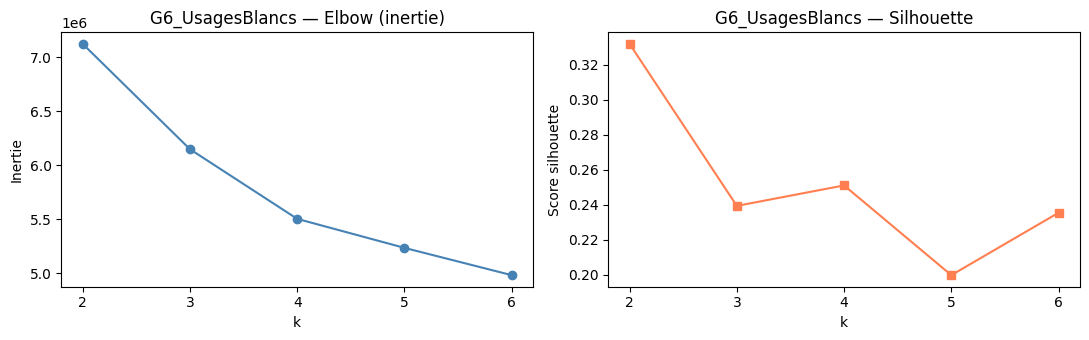

In [16]:
g = 'G6_UsagesBlancs'
cols_g6 = [c for c in GROUPES[g] if c in X.columns]

Xs_g6_tmp = StandardScaler().fit_transform(X[cols_g6].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g6)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g6_tmp, range(2, 7), name=g)
plot_elbow(k_range, inertias, sils, g)

G6_UsagesBlancs | k=3 | inertie=6,148,202
0    135409
1     98277
2    316285


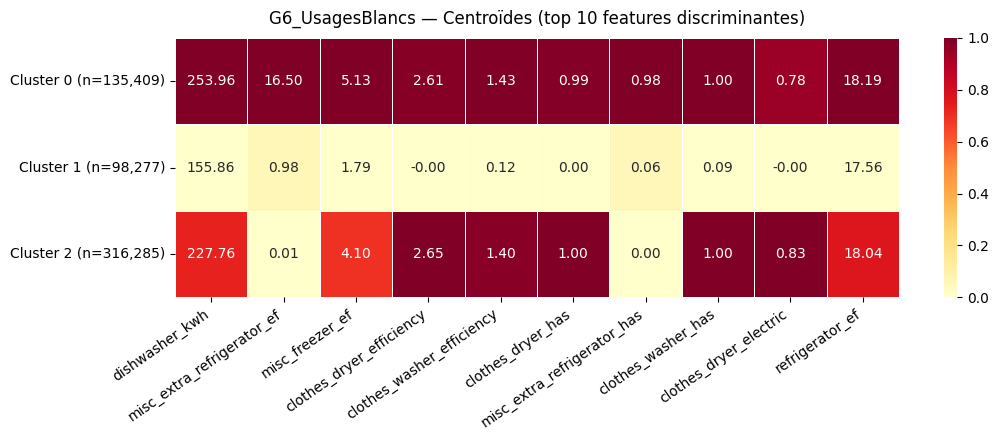

In [17]:
K_G6 = 3   # ← ajuster (ex: équipement basique / standard / premium)

labels_g6, sc_g6, km_g6, Xs_g6 = cluster_group(X, cols_g6, K_G6, g)
analyse_cluster(X, cols_g6, labels_g6, km_g6, sc_g6, g, n_top=10)

### G7 — Usages Bruns (TV, PC, chargeurs)

Elbow / silhouette pour G7_UsagesBruns (2 features) :


  k=2  inertie=627,166  silhouette=0.520


  k=3  inertie=376,356  silhouette=0.487


  k=4  inertie=343,814  silhouette=0.432


  k=5  inertie=256,323  silhouette=0.484


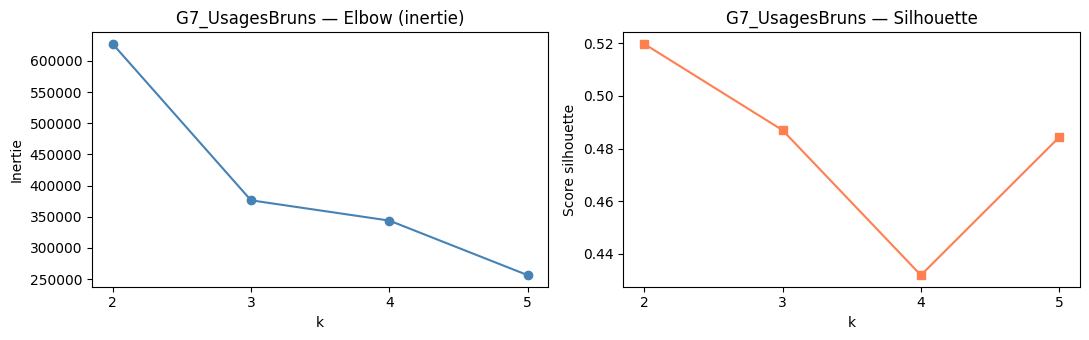

In [18]:
g = 'G7_UsagesBruns'
cols_g7 = [c for c in GROUPES[g] if c in X.columns]

Xs_g7_tmp = StandardScaler().fit_transform(X[cols_g7].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g7)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g7_tmp, range(2, 6), name=g)
plot_elbow(k_range, inertias, sils, g)

G7_UsagesBruns | k=3 | inertie=373,752
0    238483
1    133917
2    177571


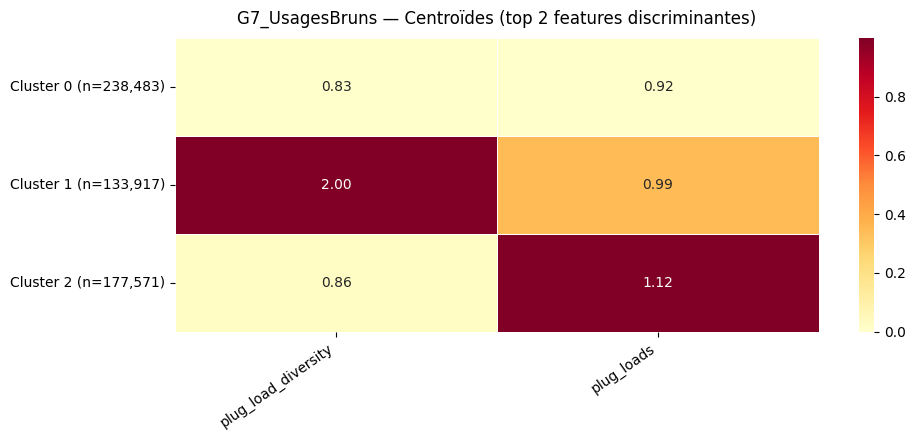

In [19]:
K_G7 = 3   # ← ajuster (ex: faible / moyen / fort usage bruns)

labels_g7, sc_g7, km_g7, Xs_g7 = cluster_group(X, cols_g7, K_G7, g)
analyse_cluster(X, cols_g7, labels_g7, km_g7, sc_g7, g, n_top=2)

---
## 5. Agrégation des clusters → Stratum composite

On concatène les labels de **tous les groupes** pour former un stratum composite.  
Pour éviter l'explosion combinatoire, on fusionne les strata dont l'effectif est < seuil.

In [20]:
# ── Collecte de tous les labels ──────────────────────────────────────────────
labels_all = {
    'G1_SocioEco'    : labels_g1,
    'G2_Occupants'   : labels_g2,
    'G3_Meteo'       : labels_g3,   # labels ASHRAE (strings : '3A', '5B'...)
    'G4a_Isolation'  : labels_g4a,
    'G4b_Geometrie'  : labels_g4b,
    'G5a_HVAC'       : labels_g5a,
    'G5b_ECS'        : labels_g5b,
    'G6_UsagesBlancs': labels_g6,
    'G7_UsagesBruns' : labels_g7,
}

df_labels = pd.DataFrame({g: l for g, l in labels_all.items()})

# Stratum composite (chaîne)
cols_strat = list(labels_all.keys())
df_labels['stratum'] = (
    df_labels[cols_strat]
    .astype(str)
    .apply(lambda row: '_'.join(row), axis=1)
)

n_strata_raw = df_labels['stratum'].nunique()
print(f'Nombre de strata bruts : {n_strata_raw}')
print(f'\nDistribution (top 20) :')
print(df_labels['stratum'].value_counts().head(20).to_string())

Nombre de strata bruts : 38129

Distribution (top 20) :
stratum
0_1_4A_0_0_3_0_1_0    1711
0_1_5A_0_0_3_0_1_0    1687
0_1_4A_0_0_3_2_1_0    1678
0_1_3B_0_0_3_2_1_0    1674
0_1_5A_0_0_3_2_1_0    1603
0_1_2A_0_0_0_0_2_2    1593
1_1_5A_2_2_0_2_2_0    1424
0_1_2A_0_0_0_0_1_2    1101
1_1_5A_2_2_2_2_2_0     967
1_1_2A_0_3_0_0_2_2     938
1_1_5A_2_2_1_2_2_0     922
0_1_3A_0_0_0_0_2_2     922
1_1_2A_0_3_1_0_2_2     863
1_1_3A_3_3_0_0_2_2     853
0_1_3A_0_0_0_0_1_2     850
1_1_2A_0_1_1_0_2_2     842
0_0_4A_0_0_3_2_1_1     786
0_1_3B_0_0_3_0_1_0     766
1_1_5A_2_2_0_0_2_0     750
0_1_3B_0_0_0_2_1_0     743


In [21]:
# ── Fusion des strata rares ───────────────────────────────────────────────────
# Un stratum doit avoir au moins MIN_STRATUM_SIZE samples pour qu'un split 80/20
# puisse lui allouer au moins 1 sample dans le test set.

MIN_STRATUM_SIZE = max(10, int(len(X) * 0.0001))   # 0.01 % du dataset
print(f'Seuil minimum par stratum : {MIN_STRATUM_SIZE} samples')

counts = df_labels['stratum'].value_counts()
rare   = counts[counts < MIN_STRATUM_SIZE].index
print(f'Strata rares (< {MIN_STRATUM_SIZE}) : {len(rare)} / {len(counts)}')

# Remplacer les rares par 'RARE'
stratum_final = df_labels['stratum'].copy()
stratum_final[stratum_final.isin(rare)] = 'RARE'

print(f'Nombre de strata après fusion : {stratum_final.nunique()}')
print(f'Taille du stratum RARE : {(stratum_final == "RARE").sum():,} ({(stratum_final == "RARE").mean()*100:.1f}%)')

Seuil minimum par stratum : 54 samples
Strata rares (< 54) : 35929 / 38129


Nombre de strata après fusion : 2201
Taille du stratum RARE : 248,031 (45.1%)


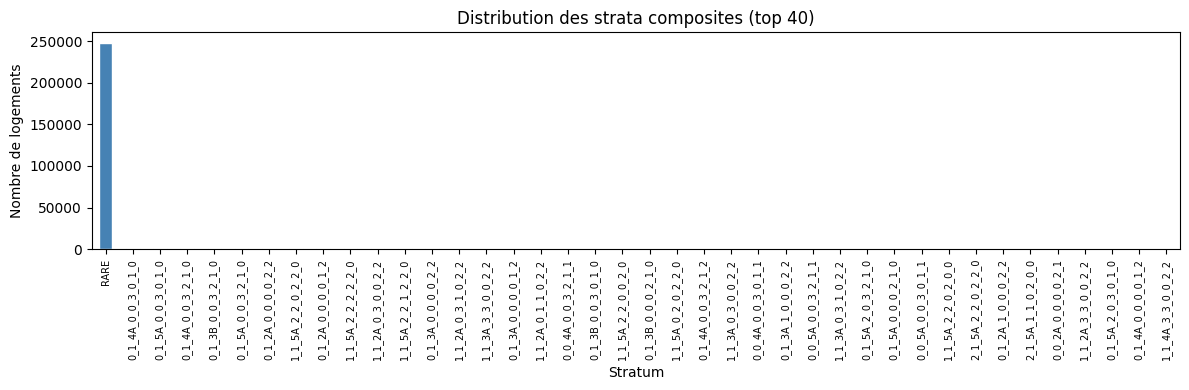

Strata couverts : 2201
Min / Médiane / Max : 54 / 92 / 248031


In [22]:
# ── Visualisation de la distribution des strata ───────────────────────────────
counts_final = stratum_final.value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
top_n = 40
counts_final.head(top_n).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set(title=f'Distribution des strata composites (top {top_n})',
       xlabel='Stratum', ylabel='Nombre de logements')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

print(f'Strata couverts : {stratum_final.nunique()}')
print(f'Min / Médiane / Max : {counts_final.min()} / {counts_final.median():.0f} / {counts_final.max()}')

---
## 6. Split Train / Test stratifié

In [23]:
idx = np.arange(len(X))

idx_train, idx_test = train_test_split(
    idx,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = stratum_final.values,
)

print(f'Train : {len(idx_train):,} ({len(idx_train)/len(X)*100:.1f}%)')
print(f'Test  : {len(idx_test):,}  ({len(idx_test)/len(X)*100:.1f}%)')

Train : 439,976 (80.0%)
Test  : 109,995  (20.0%)


In [24]:
# ── Validation de l'équilibre ─────────────────────────────────────────────────
# Pour chaque stratum, comparer la proportion train vs test

strat_train = stratum_final.iloc[idx_train].value_counts(normalize=True).rename('train')
strat_test  = stratum_final.iloc[idx_test].value_counts(normalize=True).rename('test')

df_check = pd.concat([strat_train, strat_test], axis=1).dropna()
df_check['diff_abs'] = (df_check['train'] - df_check['test']).abs()

print(f'Écart max train/test par stratum : {df_check["diff_abs"].max():.4f}')
print(f'Écart moyen                      : {df_check["diff_abs"].mean():.4f}')
print()
print('Top 10 strata les plus déséquilibrés :')
print(df_check.sort_values('diff_abs', ascending=False).head(10).to_string())

Écart max train/test par stratum : 0.0000
Écart moyen                      : 0.0000

Top 10 strata les plus déséquilibrés :
                       train      test  diff_abs
stratum                                         
2_1_3C_1_1_2_2_2_0  0.000107  0.000100  0.000007
1_1_6A_0_3_0_0_2_0  0.000107  0.000100  0.000007
1_0_3A_0_1_2_2_2_1  0.000107  0.000100  0.000007
RARE                0.450991  0.450984  0.000006
0_1_5A_0_0_3_0_1_0  0.003068  0.003064  0.000005
1_1_5A_2_2_2_2_2_0  0.001759  0.001755  0.000005
0_1_3A_0_0_0_0_2_2  0.001677  0.001673  0.000005
1_1_5A_2_2_1_2_2_0  0.001677  0.001673  0.000005
1_1_2A_0_1_1_0_2_2  0.001532  0.001527  0.000005
0_0_5A_0_0_3_2_1_1  0.001286  0.001282  0.000005


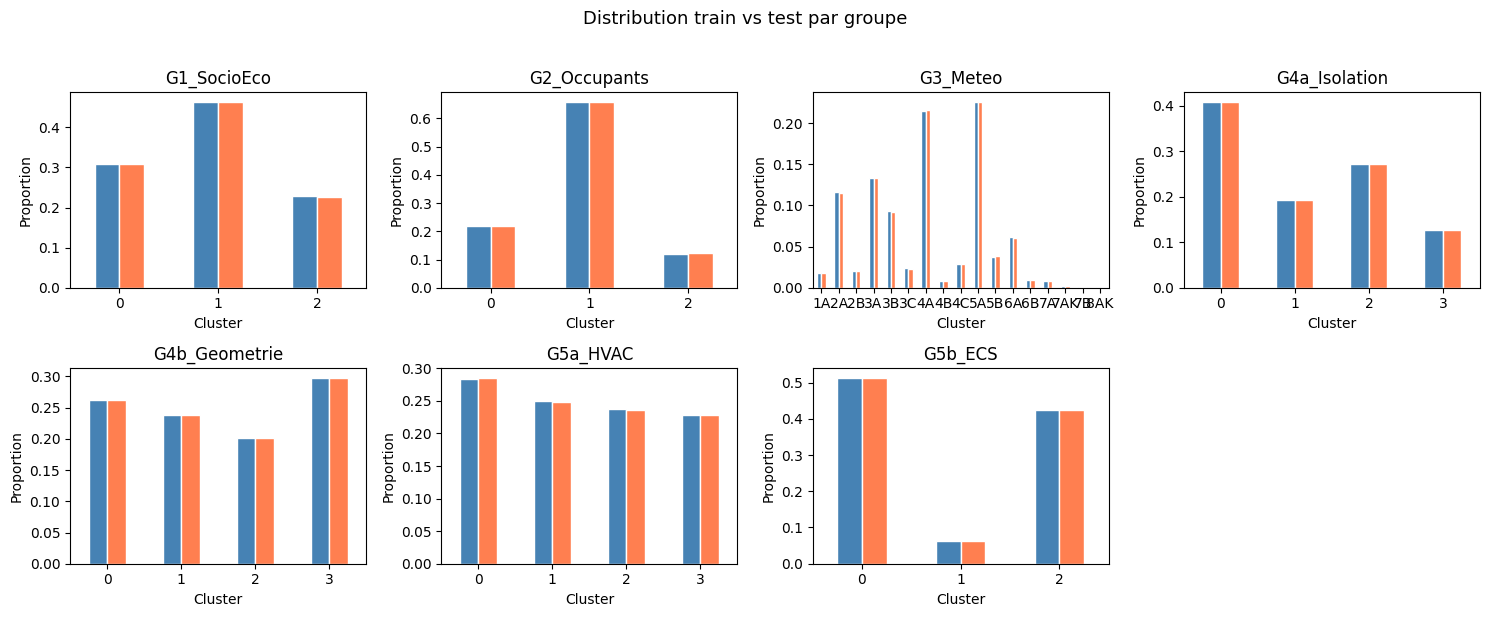

In [25]:
# ── Validation par groupe ─────────────────────────────────────────────────────
# Chaque cluster de chaque groupe doit être ~ 80 / 20 dans train / test

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()

for ax, (gname, labels) in zip(axes, labels_all.items()):
    s = pd.Series(labels)
    train_dist = s.iloc[idx_train].value_counts(normalize=True).sort_index()
    test_dist  = s.iloc[idx_test].value_counts(normalize=True).sort_index()
    df_g = pd.DataFrame({'Train': train_dist, 'Test': test_dist})
    df_g.plot(kind='bar', ax=ax, color=['steelblue','coral'],
              edgecolor='white', legend=(gname == 'G1'))
    ax.set(title=gname, xlabel='Cluster', ylabel='Proportion')
    ax.tick_params(axis='x', rotation=0)

axes[-1].set_visible(False)
plt.suptitle('Distribution train vs test par groupe', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Sauvegarde

In [26]:
# Indices
np.save(DATA_PROCESSED / 'idx_train.npy', idx_train)
np.save(DATA_PROCESSED / 'idx_test.npy',  idx_test)

# Labels de cluster par groupe + stratum final
df_labels['stratum_final'] = stratum_final.values
df_labels.to_parquet(DATA_PROCESSED / 'cluster_labels.parquet', index=False)

print('Sauvegardé :')
print(f'  idx_train.npy       → {len(idx_train):,} indices')
print(f'  idx_test.npy        → {len(idx_test):,} indices')
print(f'  cluster_labels.parquet → {df_labels.shape}')

Sauvegardé :
  idx_train.npy       → 439,976 indices
  idx_test.npy        → 109,995 indices
  cluster_labels.parquet → (549971, 11)


In [27]:
# ── Vérification rapide du split ──────────────────────────────────────────────
X_train = X.iloc[idx_train]
X_test  = X.iloc[idx_test]
Y_train = Y.iloc[idx_train]
Y_test  = Y.iloc[idx_test]

print('Split final :')
print(f'  X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'  Y_train : {Y_train.shape}  |  Y_test : {Y_test.shape}')
print()
print('Comparaison moyenne des cibles (train vs test) :')
comp = pd.DataFrame({'Train': Y_train.mean(), 'Test': Y_test.mean()})
comp['Diff %'] = ((comp['Test'] - comp['Train']) / comp['Train'] * 100).round(2)
print(comp.to_string())

Split final :
  X_train : (439976, 108)  |  X_test : (109995, 108)
  Y_train : (439976, 5)  |  Y_test : (109995, 5)

Comparaison moyenne des cibles (train vs test) :
                                                       Train          Test  Diff %
out.electricity.total.energy_consumption..kwh   11761.215069  11733.108560   -0.24
out.natural_gas.total.energy_consumption..kwh   10591.385265  10596.795497    0.05
out.fuel_oil.total.energy_consumption..kwh       1277.264799   1294.537068    1.35
out.propane.total.energy_consumption..kwh        1112.887420   1066.464874   -4.17
out.emissions.total.lrmer_mid_case_25..co2e_kg   5430.228356   5415.362802   -0.27
